# 📦 OPUS EN↔VI Corpus Downloader
**Môi trường**: Google Colab | **Mục tiêu**: Qwen 2.5 Translator

| Corpus | Ước tính cặp EN-VI | Ghi chú |
|---|---|---|
| OpenSubtitles | ~3,000,000 | Phụ đề phim |
| WikiMatrix | ~150,000 | Wikipedia song ngữ |
| TED2020 | ~350,000 | Bài nói TED |
| Tatoeba | ~10,000 | Câu đơn giản |
| QED | ~120,000 | Phụ đề giáo dục |
| KDE4 | ~90,000 | Phần mềm KDE |
| GNOME | ~20,000 | Phần mềm GNOME |
| Ubuntu | ~15,000 | Tài liệu Ubuntu |
| bible-uedin | ~30,000 | Kinh thánh |
| ELRC | ~5,000 | Y tế/Hành chính EU |

---

In [ ]:
# ============================================================
# CELL 1: MOUNT GOOGLE DRIVE (tuỳ chọn — để lưu kết quả)
# ============================================================
USE_DRIVE = True   # Đặt False nếu không dùng Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_ROOT = '/content/drive/MyDrive/opus_en_vi'
else:
    SAVE_ROOT = '/content/opus_en_vi'

print(f'📁 Save root: {SAVE_ROOT}')

Mounted at /content/drive
📁 Save root: /content/drive/MyDrive/opus_en_vi


In [ ]:
# ============================================================
# CELL 2: CÀI ĐẶT THƯ VIỆN
# ============================================================
%%capture
!pip install opustools-pkg ftfy tqdm pandas requests

In [ ]:
# ============================================================
# CELL 3: IMPORTS & SETUP
# ============================================================
import os, re, json, time, zipfile, io, logging, warnings
import requests
import pandas as pd
import ftfy
from pathlib import Path
from tqdm.notebook import tqdm
from datetime import datetime
warnings.filterwarnings('ignore')

# Paths
ROOT        = Path(SAVE_ROOT)
RAW_DIR     = ROOT / 'raw'
OUTPUT_DIR  = ROOT / 'output'
CKPT_DIR    = ROOT / 'checkpoints'
OPUS_CACHE  = ROOT / 'opus_cache'   # nơi opustools cache file .xml.gz

for d in [RAW_DIR, OUTPUT_DIR, CKPT_DIR, OPUS_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(ROOT / 'opus_download.log'),
        logging.StreamHandler()
    ]
)
log = logging.getLogger('opus')

# ---- Checkpoint helpers ----
def ckpt_load(name: str) -> dict:
    f = CKPT_DIR / f'{name}.json'
    return json.loads(f.read_text()) if f.exists() else {}

def ckpt_save(name: str, data: dict):
    (CKPT_DIR / f'{name}.json').write_text(
        json.dumps(data, ensure_ascii=False, indent=2))

print('✅ Setup xong!')
print(f'   RAW      : {RAW_DIR}')
print(f'   OUTPUT   : {OUTPUT_DIR}')
print(f'   CHECKPOINT: {CKPT_DIR}')

✅ Setup xong!
   RAW      : /content/drive/MyDrive/opus_en_vi/raw
   OUTPUT   : /content/drive/MyDrive/opus_en_vi/output
   CHECKPOINT: /content/drive/MyDrive/opus_en_vi/checkpoints


In [ ]:
# ============================================================
# CELL 4: DANH SÁCH CORPUS & CẤU HÌNH
# ============================================================

# Mỗi entry: (corpus_name, release, preprocess, max_sentences)
# max_sentences=None => tải toàn bộ
OPUS_CORPORA = [
    # corpus_name       release     preprocess   max_sents   ghi_chu
    ('OpenSubtitles',   'v2018',    'raw',        50_000,   'Phụ đề phim'),
    ('WikiMatrix',      'v1',       'raw',        50_000,      'Wikipedia song ngữ'),
    ('TED2020',         'v1',       'raw',        50_000,      'TED talks'),
    ('Tatoeba',         'v2023-04-12','raw',      50_000,      'Câu đơn giản'),
    ('QED',             'v2.0a',    'raw',        50_000,      'Phụ đề giáo dục'),
    ('KDE4',            'v2',       'raw',        50_000,      'Software KDE'),
    ('GNOME',           'v1',       'raw',        50_000,      'Software GNOME'),
    ('Ubuntu',          'v14.10',   'raw',        50_000,      'Ubuntu docs'),
    ('bible-uedin',     'v1',       'raw',        50_000,      'Kinh thánh'),
    ('ELRC_2922',       'v1',       'raw',        50_000,      'Y tế EU'),
]

SRC_LANG = 'en'
TGT_LANG = 'vi'

# Corpus nào muốn BỎ QUA — thêm tên vào đây
SKIP_CORPORA = set()
# SKIP_CORPORA = {'OpenSubtitles'}  # ví dụ bỏ qua OpenSubtitles

print(f'📋 Tổng {len(OPUS_CORPORA)} corpora được cấu hình:')
df_cfg = pd.DataFrame(OPUS_CORPORA,
    columns=['Corpus', 'Release', 'Preprocess', 'Max sentences', 'Ghi chú'])
df_cfg['Max sentences'] = df_cfg['Max sentences'].apply(
    lambda x: f'{x:,}' if x else 'All')
display(df_cfg)

📋 Tổng 10 corpora được cấu hình:


,Corpus,Release,Preprocess,Max sentences,Ghi chú
0,OpenSubtitles,v2018,raw,"50,000",Phụ đề phim
1,WikiMatrix,v1,raw,"50,000",Wikipedia song ngữ
2,TED2020,v1,raw,"50,000",TED talks
3,Tatoeba,v2023-04-12,raw,"50,000",Câu đơn giản
4,QED,v2.0a,raw,"50,000",Phụ đề giáo dục
5,KDE4,v2,raw,"50,000",Software KDE
6,GNOME,v1,raw,"50,000",Software GNOME
7,Ubuntu,v14.10,raw,"50,000",Ubuntu docs
8,bible-uedin,v1,raw,"50,000",Kinh thánh
9,ELRC_2922,v1,raw,"50,000",Y tế EU


In [ ]:
# ============================================================
# CELL 5: PHƯƠNG THỨC 1 — opustools OpusRead
# Dùng API chính thức, tải file XML gzip từ OPUS server
# ============================================================
import opustools

def download_via_opustools(corpus, release='latest', preprocess='raw',
                            max_sents=None, cache_dir=OPUS_CACHE):
    """
    Tải corpus EN-VI qua opustools.OpusRead.
    Trả về list of (en_str, vi_str).
    """
    pairs = []
    log.info(f'[opustools] {corpus} {release} ({preprocess})')

    try:
        reader = opustools.OpusRead(
            directory=corpus,
            source=SRC_LANG,
            target=TGT_LANG,
            release=release,
            preprocess=preprocess,
            leave_non_alignments_out=True,
            download_dir=str(cache_dir),
            suppress_prompts=True,
            write_mode='moses',      # xuất text thuần
        )

        # OpusRead.read_files() yields (src_sent, tgt_sent)
        count = 0
        bar_desc = f'  {corpus}'
        pbar = tqdm(desc=bar_desc, unit=' pairs',
                    total=max_sents, leave=False)

        for src, tgt in reader.read_files():
            src = ftfy.fix_text(src.strip())
            tgt = ftfy.fix_text(tgt.strip())
            if src and tgt:
                pairs.append((src, tgt))
                count += 1
                pbar.update(1)
                if max_sents and count >= max_sents:
                    break
        pbar.close()

    except Exception as e:
        log.warning(f'[opustools] {corpus} error: {e}')

    return pairs

print('✅ opustools downloader defined!')

✅ opustools downloader defined!


In [ ]:
# ============================================================
# CELL 6: PHƯƠNG THỨC 2 — Direct HTTP Download (Fallback)
# Tải file Moses (.txt.zip) trực tiếp từ OPUS CDN
# Dùng khi opustools timeout hoặc API lỗi
# ============================================================

# OPUS CDN URLs — thử lần lượt
OPUS_CDN_TEMPLATES = [
    # Moses format (sentence-aligned .txt)
    'https://object.pouta.csc.fi/OPUS-{corpus}/{release}/moses/{src}-{tgt}.txt.zip',
    'https://object.pouta.csc.fi/OPUS-{corpus}/{release}/moses/{tgt}-{src}.txt.zip',
    # Fallback: older URL pattern
    'https://opus.nlpl.eu/download.php?f={corpus}/{release}/moses/{src}-{tgt}.txt.zip',
]

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (research; parallel corpus download)',
    'Accept': '*/*',
}

def download_via_http(corpus, release='v1', max_sents=None,
                       src=SRC_LANG, tgt=TGT_LANG):
    """
    Fallback: tải Moses zip trực tiếp từ OPUS CDN.
    Trả về list of (en_str, vi_str).
    """
    pairs = []
    zip_bytes = None
    swapped   = False   # True nếu file là tgt-src thay vì src-tgt

    for template in OPUS_CDN_TEMPLATES:
        url = template.format(
            corpus=corpus, release=release, src=src, tgt=tgt)
        log.info(f'[HTTP] Trying: {url}')
        try:
            resp = requests.get(url, headers=HEADERS,
                                timeout=120, stream=True)
            if resp.status_code == 200:
                # Stream download với progress bar
                total = int(resp.headers.get('content-length', 0))
                buf = io.BytesIO()
                pbar = tqdm(total=total, unit='B', unit_scale=True,
                            desc=f'  ⬇ {corpus}', leave=False)
                for chunk in resp.iter_content(chunk_size=1 << 20):
                    buf.write(chunk)
                    pbar.update(len(chunk))
                pbar.close()
                zip_bytes = buf.getvalue()
                # Kiểm tra nếu file là tgt-src (đảo ngược)
                swapped = f'{tgt}-{src}' in url
                log.info(f'[HTTP] Downloaded {len(zip_bytes)/1e6:.1f} MB')
                break
        except Exception as e:
            log.debug(f'[HTTP] {url} failed: {e}')
            continue

    if not zip_bytes:
        log.error(f'[HTTP] {corpus}: all CDN URLs failed')
        return pairs

    # Parse zip
    try:
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
            names = z.namelist()
            log.info(f'[HTTP] Zip contents: {names}')

            # Tìm file .en và .vi
            en_file = next((n for n in names
                            if n.endswith(f'.{src}')), None)
            vi_file = next((n for n in names
                            if n.endswith(f'.{tgt}')), None)

            if not en_file or not vi_file:
                log.error(f'[HTTP] {corpus}: missing .en/.vi in zip')
                return pairs

            en_lines = z.read(en_file).decode('utf-8', errors='ignore').splitlines()
            vi_lines = z.read(vi_file).decode('utf-8', errors='ignore').splitlines()

            if swapped:
                en_lines, vi_lines = vi_lines, en_lines

            limit = max_sents or len(en_lines)
            for e, v in tqdm(
                    zip(en_lines[:limit], vi_lines[:limit]),
                    total=min(limit, len(en_lines)),
                    desc=f'  Parsing {corpus}', leave=False):
                e = ftfy.fix_text(e.strip())
                v = ftfy.fix_text(v.strip())
                if e and v:
                    pairs.append((e, v))

    except Exception as ex:
        log.error(f'[HTTP] Parse error {corpus}: {ex}')

    return pairs

print('✅ HTTP fallback downloader defined!')

✅ HTTP fallback downloader defined!


In [ ]:
# ============================================================
# CELL 7: SMART DOWNLOADER — tự động chọn phương thức
# ============================================================

# Map corpus → CDN release tag (một số corpus dùng tên khác trên CDN)
CDN_RELEASE_MAP = {
    'OpenSubtitles': 'v2018',
    'WikiMatrix':    'v1',
    'TED2020':       'v1',
    'Tatoeba':       'v2023-04-12',
    'QED':           'v2.0a',
    'KDE4':          'v2',
    'GNOME':         'v1',
    'Ubuntu':        'v14.10',
    'bible-uedin':   'v1',
    'ELRC_2922':     'v1',
}


def smart_download(corpus, release='latest', preprocess='raw',
                   max_sents=None, force_method=None):
    """
    Tải corpus với fallback tự động:
      1. opustools (API chính thức)
      2. HTTP trực tiếp (CDN)

    force_method: 'opustools' | 'http' | None (auto)
    """
    pairs = []

    methods = []
    if force_method == 'http':
        methods = ['http']
    elif force_method == 'opustools':
        methods = ['opustools']
    else:
        methods = ['opustools', 'http']   # thử opustools trước

    cdn_release = CDN_RELEASE_MAP.get(corpus, release)

    for method in methods:
        if method == 'opustools':
            pairs = download_via_opustools(
                corpus, release=release,
                preprocess=preprocess,
                max_sents=max_sents)
        elif method == 'http':
            pairs = download_via_http(
                corpus, release=cdn_release,
                max_sents=max_sents)

        if pairs:
            log.info(f'✅ {corpus}: {len(pairs):,} pairs via [{method}]')
            return pairs, method
        else:
            log.warning(f'⚠️  {corpus}: [{method}] returned 0 pairs, trying next...')

    log.error(f'❌ {corpus}: all methods failed')
    return [], 'failed'


def quality_filter(pairs):
    """
    Lọc nhanh: bỏ cặp rỗng, quá ngắn, tỉ lệ độ dài bất thường.
    """
    result = []
    for e, v in pairs:
        if not e or not v:
            continue
        le, lv = len(e), len(v)
        if le < 5 or lv < 5:
            continue
        if le > 2000 or lv > 2000:
            continue
        ratio = lv / (le + 1e-5)
        if ratio < 0.15 or ratio > 8.0:
            continue
        result.append((e, v))
    return result


def save_corpus(corpus_name, pairs, out_dir=OUTPUT_DIR):
    """Lưu CSV + metadata."""
    if not pairs:
        return None
    df = pd.DataFrame(pairs, columns=['en', 'vi'])
    df = df.drop_duplicates()
    slug = re.sub(r'[^a-z0-9]', '_', corpus_name.lower())
    path = out_dir / f'{slug}.csv'
    df.to_csv(path, index=False)
    log.info(f'💾 Saved: {path} ({len(df):,} rows)')
    return path

print('✅ Smart downloader defined!')

✅ Smart downloader defined!


In [ ]:
# ============================================================
# CELL 8: KIỂM TRA CORPUS NÀO ĐÃ CÓ EN-VI TRÊN OPUS
# (tra cứu trước khi download để tránh lỗi)
# ============================================================
import opustools

def check_corpus_availability(corpus_list):
    """
    Kiểm tra corpus nào thực sự có cặp EN-VI trên OPUS.
    Dùng OpusRead với max 1 câu để test nhanh.
    """
    results = []
    for corpus, release, preprocess, max_s, note in tqdm(
            corpus_list, desc='Checking availability'):
        if corpus in SKIP_CORPORA:
            results.append((corpus, '⏭ Skipped', note))
            continue
        try:
            reader = opustools.OpusRead(
                directory=corpus,
                source=SRC_LANG,
                target=TGT_LANG,
                release=release,
                preprocess=preprocess,
                leave_non_alignments_out=True,
                download_dir=str(OPUS_CACHE),
                suppress_prompts=True,
            )
            found = False
            for _ in reader.read_files():
                found = True
                break
            status = '✅ Available' if found else '❓ Empty'
        except Exception as e:
            status = f'❌ Error: {str(e)[:60]}'
        results.append((corpus, status, note))
        time.sleep(0.5)

    df_res = pd.DataFrame(results, columns=['Corpus', 'Status', 'Ghi chú'])
    display(df_res)
    return df_res


# Bỏ comment dòng dưới để chạy kiểm tra (mất ~2-3 phút)
# availability_df = check_corpus_availability(OPUS_CORPORA)
print('ℹ️  Bỏ comment dòng cuối để kiểm tra trước khi download')

ℹ️  Bỏ comment dòng cuối để kiểm tra trước khi download


In [ ]:
# ============================================================
# CELL 9: 🚀 MAIN DOWNLOAD LOOP
# Resume được — bỏ qua corpus đã download xong
# ============================================================

# Kết quả tổng hợp
run_stats = []   # [(corpus, n_raw, n_filtered, method, duration_s)]

print('=' * 60)
print(f'🚀 Bắt đầu download {len(OPUS_CORPORA)} corpora')
print(f'   SRC: {SRC_LANG.upper()}  →  TGT: {TGT_LANG.upper()}')
print(f'   Output: {OUTPUT_DIR}')
print('=' * 60)

main_pbar = tqdm(OPUS_CORPORA, desc='Overall', unit='corpus')

for corpus, release, preprocess, max_sents, note in main_pbar:
    main_pbar.set_postfix({'current': corpus})

    # Skip?
    if corpus in SKIP_CORPORA:
        log.info(f'⏭  Skipping {corpus}')
        run_stats.append((corpus, 0, 0, 'skipped', 0))
        continue

    # Resume check
    ckpt = ckpt_load(corpus)
    if ckpt.get('done'):
        n = ckpt.get('n_filtered', 0)
        log.info(f'⏭  Resume skip {corpus} ({n:,} pairs already saved)')
        run_stats.append((corpus, ckpt.get('n_raw',0), n, ckpt.get('method','?'), 0))
        continue

    t0 = time.time()
    log.info(f'\n{'='*50}\n🔄 {corpus} | {note}\n{'='*50}')

    # Download
    pairs_raw, method = smart_download(
        corpus, release=release,
        preprocess=preprocess,
        max_sents=max_sents
    )
    n_raw = len(pairs_raw)

    # Filter
    pairs_clean = quality_filter(pairs_raw)
    n_clean = len(pairs_clean)
    drop_pct = (1 - n_clean / max(n_raw, 1)) * 100
    log.info(f'   Raw: {n_raw:,}  →  Filtered: {n_clean:,}  (dropped {drop_pct:.1f}%)')

    # Save
    save_corpus(corpus, pairs_clean)

    elapsed = time.time() - t0
    run_stats.append((corpus, n_raw, n_clean, method, round(elapsed)))

    # Checkpoint
    ckpt_save(corpus, {
        'done': True, 'method': method,
        'n_raw': n_raw, 'n_filtered': n_clean,
        'timestamp': datetime.now().isoformat()
    })

    # Giải phóng RAM
    del pairs_raw, pairs_clean

print('\n✅ Download xong tất cả corpora!')

🚀 Bắt đầu download 10 corpora
   SRC: EN  →  TGT: VI
   Output: /content/drive/MyDrive/opus_en_vi/output


Overall:   0%|          | 0/10 [00:00<?, ?corpus/s]

  WikiMatrix:   0%|          | 0/50000 [00:00<?, ? pairs/s]

  ⬇ WikiMatrix:   0%|          | 0.00/143M [00:00<?, ?B/s]

  Parsing WikiMatrix:   0%|          | 0/50000 [00:00<?, ?it/s]

...

  Parsing bible-uedin:   0%|          | 0/50000 [00:00<?, ?it/s]

  ELRC_2922:   0%|          | 0/50000 [00:00<?, ? pairs/s]

  ⬇ ELRC_2922:   0%|          | 0.00/482k [00:00<?, ?B/s]

  Parsing ELRC_2922:   0%|          | 0/4273 [00:00<?, ?it/s]


✅ Download xong tất cả corpora!


,Corpus,Raw pairs,Filtered pairs,Method,Duration
0,OpenSubtitles,"500,000","485,525",http,-
1,WikiMatrix,"50,000","49,992",http,0m 27s
2,TED2020,"49,583","49,519",http,0m 11s
3,Tatoeba,"6,848","6,844",http,0m 3s
4,QED,"50,000","48,763",http,0m 10s
5,KDE4,"42,782","37,459",http,0m 6s
6,GNOME,149,125,http,0m 1s
7,Ubuntu,"5,056","4,831",http,0m 2s
8,bible-uedin,"50,000","50,000",http,0m 14s
9,ELRC_2922,"4,273","4,271",http,0m 3s



🎯 TỔNG CỘNG: 737,329 cặp EN-VI đã lọc


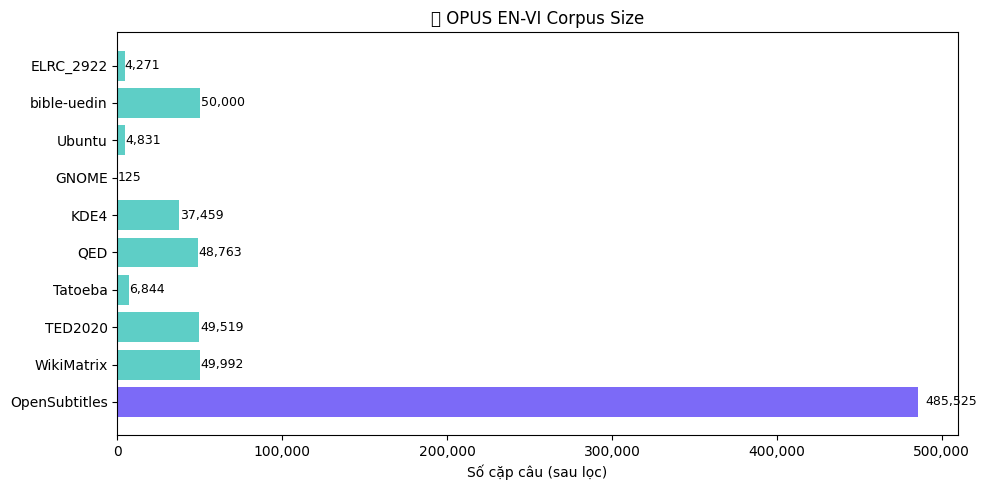

In [ ]:
# ============================================================
# CELL 10: BẢNG THỐNG KÊ KẾT QUẢ
# ============================================================
import matplotlib.pyplot as plt

df_stats = pd.DataFrame(run_stats,
    columns=['Corpus', 'Raw pairs', 'Filtered pairs', 'Method', 'Duration (s)'])

# Format
df_stats['Raw pairs']      = df_stats['Raw pairs'].apply(lambda x: f'{x:,}')
df_stats['Filtered pairs'] = df_stats['Filtered pairs'].apply(lambda x: f'{x:,}')
df_stats['Duration']       = df_stats['Duration (s)'].apply(
    lambda x: f'{x//60:.0f}m {x%60:.0f}s' if x > 0 else '-')

display(df_stats[['Corpus','Raw pairs','Filtered pairs','Method','Duration']]\
    .style.set_caption('📊 OPUS Download Results'))

# Tổng
total_filtered = sum(r[2] for r in run_stats)
print(f'\n🎯 TỔNG CỘNG: {total_filtered:,} cặp EN-VI đã lọc')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = [r[0] for r in run_stats if r[2] > 0]
counts = [r[2] for r in run_stats if r[2] > 0]
colors = ['#7c6af7' if c > 100_000 else '#5ecec6' for c in counts]
bars = ax.barh(names, counts, color=colors)
ax.set_xlabel('Số cặp câu (sau lọc)')
ax.set_title('📦 OPUS EN-VI Corpus Size')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, n in zip(bars, counts):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'corpus_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 11: MERGE TẤT CẢ CORPUS → 1 FILE DUY NHẤT
# ============================================================
from sklearn.model_selection import train_test_split

all_csvs = sorted(OUTPUT_DIR.glob('*.csv'))
print(f'📂 Tìm thấy {len(all_csvs)} file CSV:')

dfs = []
for csv_path in all_csvs:
    try:
        df_ = pd.read_csv(csv_path)
        df_['source'] = csv_path.stem
        n = len(df_)
        print(f'  {csv_path.name:<40} {n:>10,} rows')
        dfs.append(df_)
    except Exception as e:
        print(f'  ⚠️  {csv_path.name}: {e}')

df_all = pd.concat(dfs, ignore_index=True)

# Global dedup
before = len(df_all)
df_all = df_all.drop_duplicates(subset=['en', 'vi']).reset_index(drop=True)
after  = len(df_all)
print(f'\nDedup: {before:,} → {after:,} (loại {before-after:,} duplicates)')

# Shuffle
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

# Train / Val / Test split (80 / 10 / 10)
train, temp = train_test_split(df_all, test_size=0.2, random_state=42)
val, test   = train_test_split(temp,   test_size=0.5, random_state=42)

for split_name, split_df in [('train', train), ('val', val), ('test', test)]:
    path = ROOT / f'{split_name}.csv'
    split_df[['en', 'vi']].to_csv(path, index=False)
    print(f'💾 {split_name:<8}: {len(split_df):>10,} pairs → {path}')

print(f'\n✅ Total: {len(df_all):,} pairs')

📂 Tìm thấy 10 file CSV:
  bible_uedin.csv                              49,735 rows
  elrc_2922.csv                                 4,271 rows
  gnome.csv                                       124 rows
  kde4.csv                                     35,404 rows
  opensubtitles.csv                           446,542 rows
  qed.csv                                      47,020 rows
  tatoeba.csv                                   6,844 rows
  ted2020.csv                                  48,960 rows
  ubuntu.csv                                    4,816 rows
  wikimatrix.csv                               49,992 rows

Dedup: 693,708 → 689,369 (loại 4,339 duplicates)
💾 train   :    551,495 pairs → /content/drive/MyDrive/opus_en_vi/train.csv
💾 val     :     68,937 pairs → /content/drive/MyDrive/opus_en_vi/val.csv
💾 test    :     68,937 pairs → /content/drive/MyDrive/opus_en_vi/test.csv

✅ Total: 689,369 pairs


In [ ]:
# ============================================================
# CELL 12: EXPORT CHATML FORMAT CHO QWEN 2.5
# ============================================================
import json

SYSTEM_PROMPT = (
    'You are a professional English-Vietnamese translator. '
    'Translate the given text accurately, naturally, and fluently. '
    'Preserve the original meaning, tone, and style.'
)

def row_to_chatml(en: str, vi: str, direction: str) -> dict:
    """Tạo 1 sample ChatML cho Qwen 2.5."""
    if direction == 'en2vi':
        user_content = f'Translate the following text to Vietnamese:\n\n{en}'
        asst_content = vi
    else:
        user_content = f'Translate the following text to English:\n\n{vi}'
        asst_content = en
    return {
        'messages': [
            {'role': 'system',    'content': SYSTEM_PROMPT},
            {'role': 'user',      'content': user_content},
            {'role': 'assistant', 'content': asst_content},
        ]
    }


for split_name, split_df in [('train', train), ('val', val), ('test', test)]:
    out_path = ROOT / f'{split_name}_chatml.jsonl'
    count = 0
    with open(out_path, 'w', encoding='utf-8') as f:
        for _, row in tqdm(split_df.iterrows(),
                           total=len(split_df),
                           desc=f'ChatML {split_name}', leave=False):
            # Cả 2 chiều EN→VI và VI→EN
            for direction in ('en2vi', 'vi2en'):
                sample = row_to_chatml(row['en'], row['vi'], direction)
                f.write(json.dumps(sample, ensure_ascii=False) + '\n')
                count += 1
    print(f'💾 {split_name}_chatml.jsonl: {count:,} samples')

print('\n✅ ChatML export xong!')
print('\n📋 Cách dùng với Qwen 2.5:')
print('   - Framework  : LLaMA-Factory / ms-swift / Axolotl')
print('   - Format     : sharegpt / chatml')
print('   - Finetune   : QLoRA (4-bit) trên 1x A100 là đủ cho 7B')

ChatML train:   0%|          | 0/551495 [00:00<?, ?it/s]

💾 train_chatml.jsonl: 1,102,990 samples


ChatML val:   0%|          | 0/68937 [00:00<?, ?it/s]

💾 val_chatml.jsonl: 137,874 samples


ChatML test:   0%|          | 0/68937 [00:00<?, ?it/s]

💾 test_chatml.jsonl: 137,874 samples

✅ ChatML export xong!

📋 Cách dùng với Qwen 2.5:
   - Framework  : LLaMA-Factory / ms-swift / Axolotl
   - Format     : sharegpt / chatml
   - Finetune   : QLoRA (4-bit) trên 1x A100 là đủ cho 7B


In [ ]:
# ============================================================
# CELL 13: INSPECT MẪU DỮ LIỆU
# ============================================================
print('📋 10 mẫu ngẫu nhiên từ training set:\n')
sample = train[['en', 'vi']].sample(10, random_state=0)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f'[{i:02d}] EN: {row["en"][:100]}')
    print(f'     VI: {row["vi"][:100]}')
    print()

# Source distribution
print('\n📊 Phân bố theo nguồn (train set):')
print(train['source'].value_counts().to_string())

📋 10 mẫu ngẫu nhiên từ training set:

[01] EN: Shit, might be a long time before I see somethin' like that with my name on it.
     VI: Hẳn phải lâu lắm tôi mới nhìn thấy được một tờ như thế này, mà có tên mình trong đó.

[02] EN: In the name of the Father and of the Son and of the Holy Spirit.
     VI: Nhân danh Cha, Con, và các thánh thần.

[03] EN: Sure.
     VI: Chắc chắn như vậy.

[04] EN: Not at all.
     VI: Không dám.

[05] EN: These are the children of Zibeon: Aiah and Anah. This is Anah who found the hot springs in the wilde
     VI: Ðây là các con_trai của Xi-bê-ôn : Ai-gia và A-na . Ấy_là A-na có tìm đặng suối nước sôi nơi đồng vắ

[06] EN: Lightest
     VI: Nhạt nhất

[07] EN: Have you always had short hair?
     VI: Cô luôn luôn để tóc ngắn à?

[08] EN: I'll be there in a minute.
     VI: Tôi tới ngay.

[09] EN: This became the Partido Moderado (Moderate Party).
     VI: Điều này đã trở thành Partido Moderado (Đảng Trung).

[10] EN: Alekhine Defense: Modern.
     VI: Phòn

In [ ]:
# ============================================================
# CELL 14: TROUBLESHOOTING — Manual HTTP download từng corpus
# Dùng khi opustools bị lỗi với 1 corpus cụ thể
# ============================================================

# Thay CORPUS_NAME bằng tên corpus muốn download lại
CORPUS_NAME = 'WikiMatrix'
CDN_RELEASE = CDN_RELEASE_MAP.get(CORPUS_NAME, 'v1')
MAX_SENTS   = None   # None = tất cả

print(f'🔧 Manual download: {CORPUS_NAME} (HTTP, release={CDN_RELEASE})')
pairs = download_via_http(CORPUS_NAME, release=CDN_RELEASE,
                           max_sents=MAX_SENTS)
pairs = quality_filter(pairs)
print(f'   {len(pairs):,} cặp sau lọc')
if pairs:
    save_corpus(CORPUS_NAME, pairs)
    print(f'   Đã lưu → {OUTPUT_DIR}/{CORPUS_NAME.lower()}.csv')

🔧 Manual download: WikiMatrix (HTTP, release=v1)


  ⬇ WikiMatrix:   0%|          | 0.00/143M [00:00<?, ?B/s]

  Parsing WikiMatrix:   0%|          | 0/1073752 [00:00<?, ?it/s]

   1,073,536 cặp sau lọc
   Đã lưu → /content/drive/MyDrive/opus_en_vi/output/wikimatrix.csv


In [ ]:
# ============================================================
# CELL 15: RESET CHECKPOINT (nếu muốn download lại từ đầu)
# ============================================================
import shutil

RESET_CORPUS = None  # None = reset tất cả; hoặc tên 1 corpus

if RESET_CORPUS:
    ckpt_file = CKPT_DIR / f'{RESET_CORPUS}.json'
    if ckpt_file.exists():
        ckpt_file.unlink()
        print(f'🔄 Reset checkpoint: {RESET_CORPUS}')
    else:
        print(f'ℹ️  Không tìm thấy checkpoint: {RESET_CORPUS}')
else:
    # Reset tất cả
    # ⚠️  BỎ COMMENT để chạy!
    # shutil.rmtree(CKPT_DIR)
    # CKPT_DIR.mkdir()
    # print('🔄 Reset TẤT CẢ checkpoints')
    print('ℹ️  Bỏ comment block để reset tất cả checkpoints')

ℹ️  Bỏ comment block để reset tất cả checkpoints
